In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [65]:
torch.manual_seed(42)

device = torch.device("mps")
device

device(type='mps')

In [66]:
df = pd.read_csv('data/fashion-mnist_train.csv', nrows=10000)
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


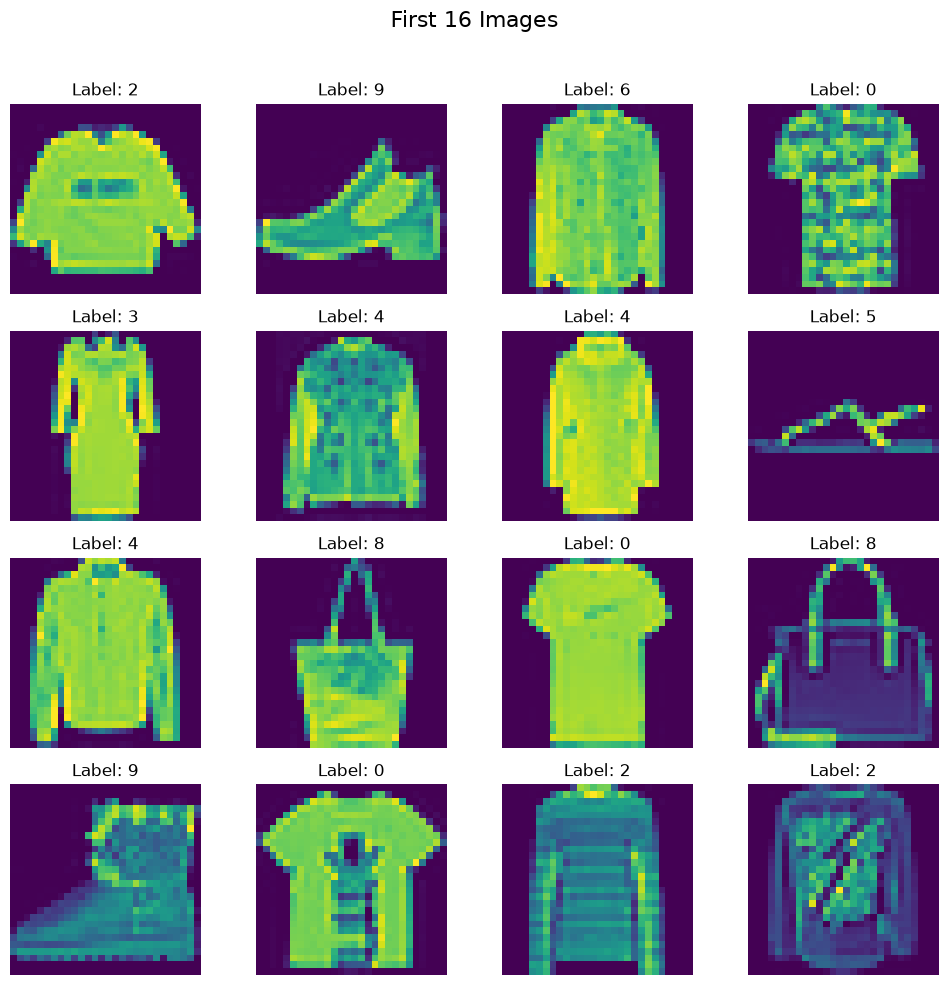

In [67]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}") # show the label

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [68]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
# scalling the features
X_train = X_train/255.0
X_test = X_test/255.0

X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(8000, 784))

In [71]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32).reshape(-1, 1, 28,28)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):

        return self.features[index], self.labels[index]
        

In [72]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [73]:
len(train_dataset)

8000

In [74]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory= True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory= True)

In [75]:
class SimpleRNN(nn.Module):

    def __init__(self, input_feature):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(input_feature, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Dropout(p=0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.4),

            nn.Linear(64, 10)
        )

        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [76]:
# set learning and ecpoch

epochs = 100
learning_rate = 0.1


In [77]:
#instatiate the model
model = SimpleRNN(1)
model.to(device)

#loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(), lr= learning_rate, weight_decay=1e-4)

In [78]:
#traning loop
for epochs in range(epochs):
    totla_epochs_loss = 0
    for batch_features, batch_lables in train_loader:

        batch_features, batch_lables = batch_features.to(device), batch_lables.to(device)

        # inilalized the model
        outputs = model(batch_features)

        # calcualte loss
        loss = criterion(outputs, batch_lables)

        # no gradation calucalation
        optimizer.zero_grad()

        # calculate the derviative
        loss.backward()
        
        # update the paramaters
        optimizer.step()

        totla_epochs_loss = totla_epochs_loss + loss.item()
    avgerage_loss = totla_epochs_loss / len(train_loader)

    print(f'Epoch: {epochs + 1}, Loss: {avgerage_loss}')


/Users/bikaschaudharytharu/python/pytorch/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch: 1, Loss: 0.8670286927223205
Epoch: 2, Loss: 0.5934748169779778
Epoch: 3, Loss: 0.5149110085964202
Epoch: 4, Loss: 0.4440686815977097
Epoch: 5, Loss: 0.39278662353754046
Epoch: 6, Loss: 0.4001243269443512
Epoch: 7, Loss: 0.35642362731695176
Epoch: 8, Loss: 0.3558139143884182
Epoch: 9, Loss: 0.31386917912960055
Epoch: 10, Loss: 0.28776032745838165
Epoch: 11, Loss: 0.270564263895154
Epoch: 12, Loss: 0.26458705657720566
Epoch: 13, Loss: 0.2479323568716645
Epoch: 14, Loss: 0.22603948740661145
Epoch: 15, Loss: 0.22314294129610063
Epoch: 16, Loss: 0.19796144180372358
Epoch: 17, Loss: 0.1830023107305169
Epoch: 18, Loss: 0.1903041802085936
Epoch: 19, Loss: 0.17283978046104312
Epoch: 20, Loss: 0.149878344993107
Epoch: 21, Loss: 0.14944727177917957
Epoch: 22, Loss: 0.14802867394220084
Epoch: 23, Loss: 0.14957252268120647
Epoch: 24, Loss: 0.12891929812449962
Epoch: 25, Loss: 0.13688846928440035
Epoch: 26, Loss: 0.12150111644342541
Epoch: 27, Loss: 0.12294814506359399
Epoch: 28, Loss: 0.1017

In [79]:
#set model to eval mode
model.eval()

SimpleRNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [80]:
#evaluation code

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        output = model(batch_features)

        _,predicted = torch.max(output, 1)

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.887


In [81]:
#evaluation code

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        output = model(batch_features)

        _,predicted = torch.max(output, 1)

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9995
